# Online Retail II — Unsupervised Customer Segmentation (RFM)

**Business goal.** Split a retail customer base into actionable segments so marketing,
pricing, and retention budgets go where they earn the most. Typical uses: VIP
retention offers, win-back campaigns for lapsed high-value buyers, and light-touch
automation for low-engagement shoppers.

**What this notebook produces.** Discovered customer segments from **unsupervised**
clustering on engineered RFM features (Recency, Frequency, Monetary), validated with
**internal** cluster-quality metrics and business-readable segment profiles.

## Important: this is unsupervised learning

The Online Retail II dataset has **no ground-truth "segment" label**. There is
**no accuracy, no confusion matrix, and no classification report**. "Metrics" here
means **internal cluster-validation** scores:

- **Silhouette Score** (higher is better; roughly −1 to 1)
- **Davies–Bouldin Index** (lower is better)
- **Calinski–Harabasz Index** (higher is better)

plus descriptive **segment profiles** (size, mean RFM, share of total spend).

We will (1) survey several algorithms with **PyCaret**, (2) pick the best **two**
from that survey using the metrics above, then (3) re-implement those two carefully
with **scikit-learn**, including a real search for the number of clusters.

## 1. Setup

Shared project kernel: `customer-segmentation-project` (uv-managed). We pin a seed
so re-runs are stable enough to compare.

In [1]:
from __future__ import annotations

import io
import random
import sys
import time
import warnings
import zipfile
from pathlib import Path

# Ensure figures embed in executed .ipynb outputs under nbconvert
import matplotlib

matplotlib.use("module://matplotlib_inline.backend_inline")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import (
    AffinityPropagation,
    AgglomerativeClustering,
    Birch,
    DBSCAN,
    KMeans,
    MeanShift,
    OPTICS,
    SpectralClustering,
    estimate_bandwidth,
)
from sklearn.decomposition import PCA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.titlesize"] = 12

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib
import pycaret
import sklearn
import ucimlrepo

print("Python:", sys.version.split()[0])
print("Kernel expectation: customer-segmentation-project")
print("pycaret:", pycaret.__version__)
print("sklearn:", sklearn.__version__)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)
print("ucimlrepo:", getattr(ucimlrepo, "__version__", "installed"))
print("Project root:", PROJECT_ROOT)

Python: 3.13.13
Kernel expectation: customer-segmentation-project
pycaret: 4.0.0a8
sklearn: 1.9.0
pandas: 3.0.3
numpy: 2.5.1
matplotlib: 3.11.0
seaborn: 0.13.2
ucimlrepo: installed
Project root: /home/ahmad/AI/Customer Segmentation


## 2. Data acquisition — UCI Online Retail II (id 502, CC BY 4.0)

Spec path is `fetch_ucirepo(id=502)`. As of this environment, UCI marks the dataset
as present but **not available for Python import** via `ucimlrepo`. We try that first
(honest attempt), then fall back to the **official UCI static zip** for the same
dataset id (`online+retail+ii.zip` → `online_retail_II.xlsx`).

Columns (transactional, no per-customer label):
`Invoice`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`, `Price`,
`Customer ID`, `Country`. Invoices starting with `C` are cancellations.

In [2]:
from ucimlrepo import fetch_ucirepo

UCI_ZIP_URL = "https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip"
ZIP_PATH = DATA_DIR / "online_retail_ii.zip"
XLSX_PATH = DATA_DIR / "online_retail_II.xlsx"


def _ensure_online_retail_ii_xlsx() -> Path:
    """Ensure the official UCI Online Retail II workbook is on disk."""
    if XLSX_PATH.exists() and XLSX_PATH.stat().st_size > 1_000_000:
        return XLSX_PATH

    import urllib.request

    print(f"Downloading official UCI zip → {ZIP_PATH}")
    urllib.request.urlretrieve(UCI_ZIP_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(DATA_DIR)
    if not XLSX_PATH.exists():
        # name may differ after extract; find xlsx
        matches = list(DATA_DIR.glob("**/*.[xX][lL][sS][xX]"))
        if not matches:
            raise FileNotFoundError(f"No xlsx found under {DATA_DIR} after unzip")
        return matches[0]
    return XLSX_PATH


def load_online_retail_ii() -> tuple[pd.DataFrame, str]:
    """Load Online Retail II; return (frame, source_description).

    Primary attempt: ucimlrepo id=502 (required by project spec).
    Reliable fallback: official UCI static zip for the same dataset id.
    """
    try:
        retail_ii = fetch_ucirepo(id=502)
        X = retail_ii.data.features
        if X is not None and len(X):
            print("targets object:", retail_ii.data.targets)
            return X.copy(), "ucimlrepo fetch_ucirepo(id=502).data.features"
        if retail_ii.data.original is not None and len(retail_ii.data.original):
            return (
                retail_ii.data.original.copy(),
                "ucimlrepo fetch_ucirepo(id=502).data.original",
            )
        print("ucimlrepo returned empty frames; using official UCI zip.")
    except Exception as exc:
        print(
            "ucimlrepo(id=502) not importable in this environment "
            f"({type(exc).__name__}); using official UCI static zip for the same dataset."
        )

    xlsx = _ensure_online_retail_ii_xlsx()
    xl = pd.ExcelFile(xlsx)
    frames = [pd.read_excel(xlsx, sheet_name=s) for s in xl.sheet_names]
    raw = pd.concat(frames, ignore_index=True)
    if raw.empty:
        raise RuntimeError("Online Retail II loaded empty after zip fallback")
    return raw, f"UCI static zip ({UCI_ZIP_URL}); sheets={xl.sheet_names}; file={xlsx.name}"


raw, data_source = load_online_retail_ii()
print("Data source:", data_source)
print("Shape:", raw.shape)
print("Columns:", list(raw.columns))
assert raw.shape[0] > 100_000, f"unexpectedly small Online Retail II: {raw.shape}"
assert {"Invoice", "Customer ID", "Price", "Quantity", "InvoiceDate"}.issubset(raw.columns)
display(raw.head())
print("\ndtypes:")
print(raw.dtypes)

ucimlrepo(id=502) not importable in this environment (DatasetNotFoundError); using official UCI static zip for the same dataset.


Data source: UCI static zip (https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip); sheets=['Year 2009-2010', 'Year 2010-2011']; file=online_retail_II.xlsx
Shape: (1067371, 8)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom



dtypes:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object


## 3. Exploratory data analysis (transaction level)

We explore **before** collapsing to one row per customer. After RFM aggregation,
invoice-level time patterns and country mix disappear — so capture them now.

In [3]:
print("Shape:", raw.shape)
print("\nMissing values:")
miss = raw.isna().sum().to_frame("n_missing")
miss["pct"] = 100 * miss["n_missing"] / len(raw)
display(miss)

# Normalize column access
assert "Invoice" in raw.columns
assert "Customer ID" in raw.columns
assert "Price" in raw.columns

raw = raw.copy()
raw["Invoice"] = raw["Invoice"].astype(str)
raw["InvoiceDate"] = pd.to_datetime(raw["InvoiceDate"], errors="coerce")
raw["is_cancel"] = raw["Invoice"].str.startswith("C")

print(f"\nCancellation rows: {raw['is_cancel'].sum():,} ({100*raw['is_cancel'].mean():.2f}%)")
print(f"Unique invoices: {raw['Invoice'].nunique():,}")
print(f"Unique customers (incl. missing ID): {raw['Customer ID'].nunique(dropna=True):,}")
print(f"Missing Customer ID rows: {raw['Customer ID'].isna().sum():,}")
print(f"Date range: {raw['InvoiceDate'].min()} → {raw['InvoiceDate'].max()}")

Shape: (1067371, 8)

Missing values:


,n_missing,pct
Invoice,0,0.000000
StockCode,0,0.000000
Description,4382,0.410541
Quantity,0,0.000000
InvoiceDate,0,0.000000
Price,0,0.000000
Customer ID,243007,22.766873
Country,0,0.000000



Cancellation rows: 19,494 (1.83%)
Unique invoices: 53,628
Unique customers (incl. missing ID): 5,942
Missing Customer ID rows: 243,007
Date range: 2009-12-01 07:45:00 → 2011-12-09 12:50:00


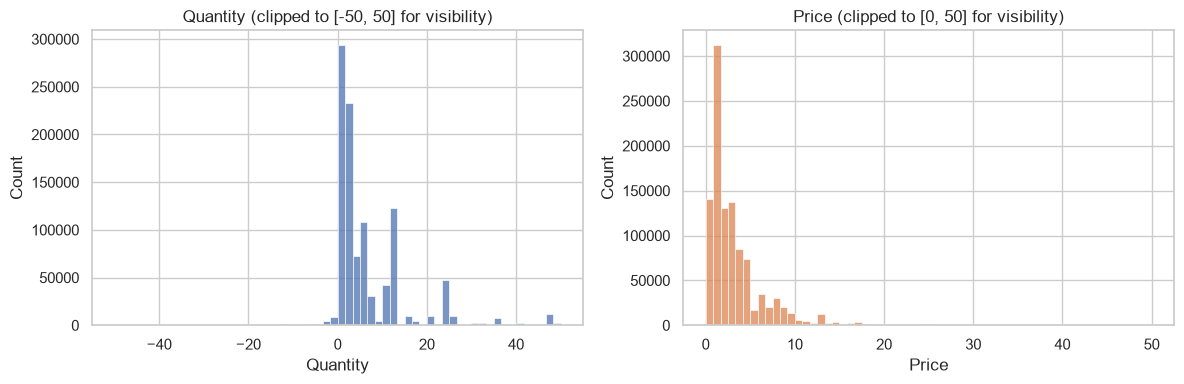

Quantity describe:
 count    1.067371e+06
mean     9.938898e+00
std      1.727058e+02
min     -8.099500e+04
25%      1.000000e+00
50%      3.000000e+00
75%      1.000000e+01
max      8.099500e+04
Name: Quantity, dtype: float64

Price describe:
 count    1.067371e+06
mean     4.649388e+00
std      1.235531e+02
min     -5.359436e+04
25%      1.250000e+00
50%      2.100000e+00
75%      4.150000e+00
max      3.897000e+04
Name: Price, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(raw.loc[raw["Quantity"].between(-50, 50), "Quantity"], bins=60, ax=axes[0])
axes[0].set_title("Quantity (clipped to [-50, 50] for visibility)")
sns.histplot(raw.loc[raw["Price"].between(0, 50), "Price"], bins=60, ax=axes[1], color="C1")
axes[1].set_title("Price (clipped to [0, 50] for visibility)")
plt.tight_layout()
plt.show()

print("Quantity describe:\n", raw["Quantity"].describe())
print("\nPrice describe:\n", raw["Price"].describe())

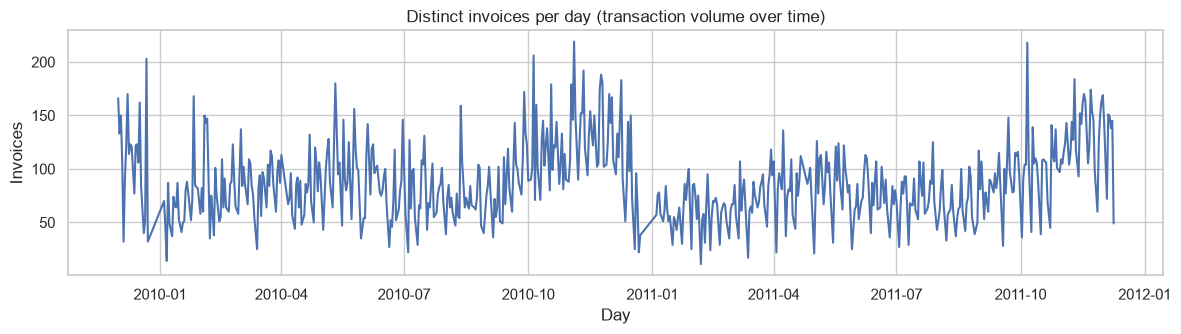

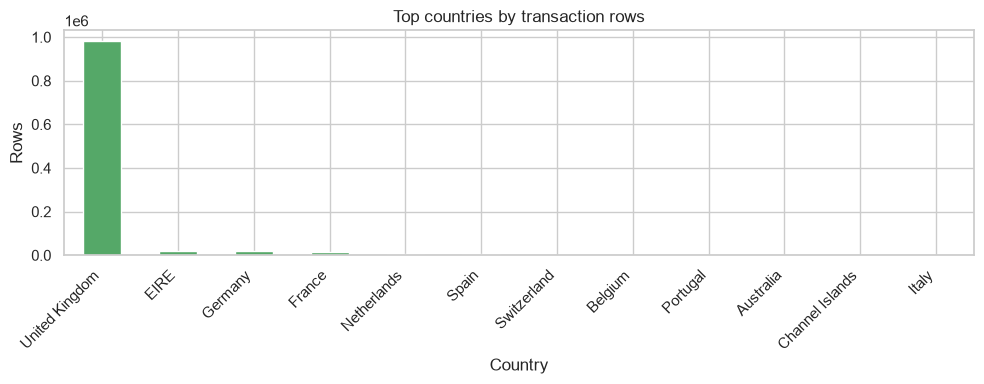

,n_rows
Country,
United Kingdom,981330
EIRE,17866
Germany,17624
France,14330
Netherlands,5140
Spain,3811
Switzerland,3189
Belgium,3123
Portugal,2620


In [5]:
daily = (
    raw.dropna(subset=["InvoiceDate"])
    .assign(day=lambda d: d["InvoiceDate"].dt.date)
    .groupby("day")["Invoice"]
    .nunique()
    .sort_index()
)
fig, ax = plt.subplots(figsize=(12, 3.5))
daily.plot(ax=ax)
ax.set_title("Distinct invoices per day (transaction volume over time)")
ax.set_xlabel("Day")
ax.set_ylabel("Invoices")
plt.tight_layout()
plt.show()

country_counts = raw["Country"].value_counts().head(12)
fig, ax = plt.subplots(figsize=(10, 4))
country_counts.plot(kind="bar", ax=ax, color="C2")
ax.set_title("Top countries by transaction rows")
ax.set_ylabel("Rows")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
display(country_counts.to_frame("n_rows"))

## 4. Feature engineering — RFM per customer

**Cleaning rules**
1. Drop cancellation invoices (`Invoice` starts with `C`)
2. Drop missing `Customer ID`
3. Keep only `Quantity > 0` and `Price > 0`

**RFM definitions** (relative to this dataset’s own max date)
- **Recency**: days since last purchase
- **Frequency**: number of distinct invoices
- **Monetary**: sum of `Quantity × Price`

Frequency and Monetary are almost always right-skewed in retail. We check skew on
*this* data, then log-transform if the numbers justify it, then `StandardScaler`
so Euclidean-distance clusterers are not dominated by raw magnitude.

In [6]:
tx = raw.loc[
    (~raw["is_cancel"])
    & raw["Customer ID"].notna()
    & (raw["Quantity"] > 0)
    & (raw["Price"] > 0)
].copy()
tx["line_total"] = tx["Quantity"] * tx["Price"]
print(f"Raw rows: {len(raw):,}")
print(f"Cleaned transaction rows: {len(tx):,}")
print(f"Customers after clean: {tx['Customer ID'].nunique():,}")

snapshot = tx["InvoiceDate"].max()
print("Snapshot (max InvoiceDate):", snapshot)

rfm = (
    tx.groupby("Customer ID")
    .agg(
        Recency=("InvoiceDate", lambda s: (snapshot - s.max()).days),
        Frequency=("Invoice", "nunique"),
        Monetary=("line_total", "sum"),
    )
    .reset_index()
)
rfm["Customer ID"] = rfm["Customer ID"].astype(int)
print("RFM shape:", rfm.shape)
display(rfm.head())
display(rfm[["Recency", "Frequency", "Monetary"]].describe())

Raw rows: 1,067,371
Cleaned transaction rows: 805,549
Customers after clean: 5,878
Snapshot (max InvoiceDate): 2011-12-09 12:50:00


RFM shape: (5878, 4)


,Customer ID,Recency,Frequency,Monetary
0,12346,325,12,77556.46
1,12347,1,8,5633.32
2,12348,74,5,2019.40
3,12349,18,4,4428.69
4,12350,309,1,334.40


,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,200.331916,6.289384,3018.616737
std,209.338707,13.009406,14737.731040
min,0.000000,1.000000,2.950000
25%,25.000000,1.000000,348.762500
50%,95.000000,3.000000,898.915000
75%,379.000000,7.000000,2307.090000
max,738.000000,398.000000,608821.650000


Skewness (raw RFM):
Recency       0.887198
Frequency    12.639951
Monetary     25.314235
dtype: float64


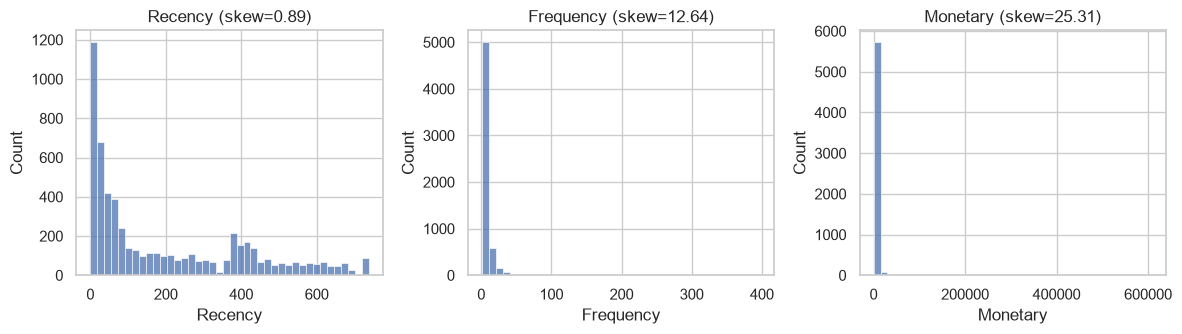

Applying log1p to Frequency (skew=12.64 > 1)
Applying log1p to Monetary (skew=25.31 > 1)
Clustering features: ['Recency', 'log_Frequency', 'log_Monetary']
Scaled feature means (≈0): {'Recency': -0.0, 'log_Frequency': 0.0, 'log_Monetary': -0.0}
Scaled feature stds (≈1): {'Recency': 1.0001, 'log_Frequency': 1.0001, 'log_Monetary': 1.0001}


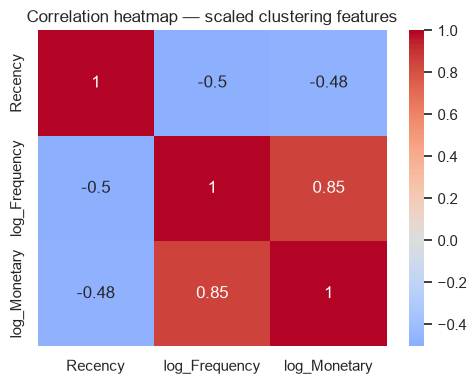

In [7]:
feat_cols = ["Recency", "Frequency", "Monetary"]
skew_vals = rfm[feat_cols].skew()
print("Skewness (raw RFM):")
print(skew_vals)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, col in zip(axes, feat_cols):
    sns.histplot(rfm[col], bins=40, ax=ax)
    ax.set_title(f"{col} (skew={skew_vals[col]:.2f})")
plt.tight_layout()
plt.show()

# Log-transform F and M when right-skew is material (threshold ~1.0)
log_cols = []
for col in ["Frequency", "Monetary"]:
    if skew_vals[col] > 1.0:
        log_cols.append(col)
        print(f"Applying log1p to {col} (skew={skew_vals[col]:.2f} > 1)")
    else:
        print(f"Keeping {col} unlogged (skew={skew_vals[col]:.2f})")

rfm_model = rfm.copy()
for col in log_cols:
    rfm_model[f"log_{col}"] = np.log1p(rfm_model[col])

cluster_feature_names = ["Recency"] + [
    f"log_{c}" if c in log_cols else c for c in ["Frequency", "Monetary"]
]
print("Clustering features:", cluster_feature_names)

X_unscaled = rfm_model[cluster_feature_names].to_numpy(dtype=float)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unscaled)
rfm_scaled = pd.DataFrame(X_scaled, columns=cluster_feature_names, index=rfm.index)
print("Scaled feature means (≈0):", rfm_scaled.mean().round(4).to_dict())
print("Scaled feature stds (≈1):", rfm_scaled.std().round(4).to_dict())

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(rfm_scaled.corr(), annot=True, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation heatmap — scaled clustering features")
plt.tight_layout()
plt.show()

## 5. Part 1 — PyCaret algorithm survey

PyCaret is a **survey tool**, not the final answer. We fit several clustering
algorithms on the **already log+scaled** RFM matrix (`normalize=False` so we do
not double-scale), then compute Silhouette / Davies–Bouldin / Calinski–Harabasz
ourselves (PyCaret 4.x alpha’s `metrics`/`pull()` may be empty — verified in this
environment).

Density methods (DBSCAN / OPTICS) can label points as **noise (−1)**. A high
Silhouette on the non-noise subset with a huge noise pile is **not** a free win —
we factor noise fraction into the best-2 pick.

In [8]:
from pycaret.clustering import ClusteringExperiment

cluster_df = rfm_scaled.copy()
print("Survey matrix shape:", cluster_df.shape)

t0 = time.time()
exp = ClusteringExperiment(session_id=SEED, normalize=False).fit(cluster_df)
print(f"PyCaret setup seconds: {time.time() - t0:.1f}")
available = exp.models()
print("Available models:")
display(available)

# Prefer a broad survey; skip notoriously slow ones on large N if needed
N = len(cluster_df)
candidate_ids = ["kmeans", "hclust", "birch", "dbscan", "optics", "sc", "meanshift", "ap"]
candidate_ids = [m for m in candidate_ids if m in available.index]
# Spectral / AP scale poorly; still try but with a soft time budget
print("Candidates:", candidate_ids)


def parse_cluster_labels(series: pd.Series) -> np.ndarray:
    s = series.astype(str).str.replace("Cluster ", "", regex=False)
    return pd.to_numeric(s, errors="coerce").fillna(-1).astype(int).to_numpy()


def internal_metrics(X: np.ndarray, labels: np.ndarray) -> dict:
    labels = np.asarray(labels)
    mask = labels >= 0
    n_noise = int((~mask).sum())
    n = int(mask.sum())
    uniq = sorted(set(labels[mask].tolist())) if n else []
    out = {
        "n_clusters": len(uniq),
        "n_noise": n_noise,
        "noise_pct": 100.0 * n_noise / len(labels) if len(labels) else np.nan,
        "largest_cluster_pct": np.nan,
        "silhouette": np.nan,
        "davies_bouldin": np.nan,
        "calinski_harabasz": np.nan,
    }
    if not uniq:
        return out
    sizes = pd.Series(labels[mask]).value_counts()
    out["largest_cluster_pct"] = 100.0 * sizes.iloc[0] / n
    if len(uniq) >= 2 and n > len(uniq):
        out["silhouette"] = float(silhouette_score(X[mask], labels[mask]))
        out["davies_bouldin"] = float(davies_bouldin_score(X[mask], labels[mask]))
        out["calinski_harabasz"] = float(calinski_harabasz_score(X[mask], labels[mask]))
    return out


survey_rows = []
TIME_BUDGET_SEC = 180  # soft per-model budget

for mid in candidate_ids:
    print(f"\n--- Survey: {mid} ---")
    t1 = time.time()
    try:
        kwargs = {}
        if mid in {"kmeans", "hclust", "birch", "sc"}:
            kwargs["num_clusters"] = 4  # survey default; Part 2 retunes k
        res = exp.create_model(mid, verbose=False, **kwargs)
        elapsed = time.time() - t1
        if elapsed > TIME_BUDGET_SEC:
            print(f"  note: {mid} took {elapsed:.1f}s (> {TIME_BUDGET_SEC}s budget)")
        labelled = exp.assign_model(res.pipeline)
        y = parse_cluster_labels(labelled["Cluster"])
        m = internal_metrics(X_scaled, y)
        row = {"model": mid, "seconds": round(elapsed, 2), "error": "", **m}
        print(row)
        survey_rows.append(row)
    except Exception as exc:
        elapsed = time.time() - t1
        print(f"  FAIL after {elapsed:.1f}s: {exc}")
        survey_rows.append(
            {
                "model": mid,
                "seconds": round(elapsed, 2),
                "error": str(exc),
                "n_clusters": np.nan,
                "n_noise": np.nan,
                "noise_pct": np.nan,
                "largest_cluster_pct": np.nan,
                "silhouette": np.nan,
                "davies_bouldin": np.nan,
                "calinski_harabasz": np.nan,
            }
        )

survey = pd.DataFrame(survey_rows)
print("\n=== Full PyCaret survey comparison ===")
display(survey.sort_values("silhouette", ascending=False, na_position="last"))

Survey matrix shape: (5878, 3)


PyCaret setup seconds: 0.5
Available models:


,Name,Reference,Turbo
ID,,,
kmeans,K-Means Clustering,sklearn.cluster._kmeans.KMeans,False
ap,Affinity Propagation,sklearn.cluster._affinity_propagation.Affinity...,False
meanshift,Mean Shift Clustering,sklearn.cluster._mean_shift.MeanShift,False
sc,Spectral Clustering,sklearn.cluster._spectral.SpectralClustering,False
hclust,Agglomerative Clustering,sklearn.cluster._agglomerative.AgglomerativeCl...,False
dbscan,Density-Based Spatial Clustering,sklearn.cluster._dbscan.DBSCAN,False
optics,OPTICS Clustering,sklearn.cluster._optics.OPTICS,False
birch,Birch Clustering,sklearn.cluster._birch.Birch,False


Candidates: ['kmeans', 'hclust', 'birch', 'dbscan', 'optics', 'sc', 'meanshift', 'ap']

--- Survey: kmeans ---


{'model': 'kmeans', 'seconds': 0.27, 'error': '', 'n_clusters': 4, 'n_noise': 0, 'noise_pct': 0.0, 'largest_cluster_pct': np.float64(35.11398434841783), 'silhouette': 0.3847021785950023, 'davies_bouldin': 0.92533417306982, 'calinski_harabasz': 5258.221709871387}

--- Survey: hclust ---


...

{'model': 'optics', 'seconds': 195.56, 'error': '', 'n_clusters': 317, 'n_noise': 3355, 'noise_pct': 57.07723715549507, 'largest_cluster_pct': np.float64(0.9116131589377725), 'silhouette': 0.5473128496237005, 'davies_bouldin': 0.558698667651364, 'calinski_harabasz': 4152.846345389298}

--- Survey: sc ---


{'model': 'sc', 'seconds': 7.71, 'error': '', 'n_clusters': 4, 'n_noise': 0, 'noise_pct': 0.0, 'largest_cluster_pct': np.float64(99.59169785641375), 'silhouette': 0.5433043668539639, 'davies_bouldin': 0.928305617683607, 'calinski_harabasz': 83.05598440358038}

--- Survey: meanshift ---


{'model': 'meanshift', 'seconds': 32.08, 'error': '', 'n_clusters': 1, 'n_noise': 0, 'noise_pct': 0.0, 'largest_cluster_pct': np.float64(100.0), 'silhouette': nan, 'davies_bouldin': nan, 'calinski_harabasz': nan}

--- Survey: ap ---


{'model': 'ap', 'seconds': 69.92, 'error': '', 'n_clusters': 595, 'n_noise': 0, 'noise_pct': 0.0, 'largest_cluster_pct': np.float64(2.1435862538278325), 'silhouette': 0.18388817433303684, 'davies_bouldin': 0.7277314050187832, 'calinski_harabasz': 463.8771546424667}

=== Full PyCaret survey comparison ===


,model,seconds,error,n_clusters,n_noise,noise_pct,largest_cluster_pct,silhouette,davies_bouldin,calinski_harabasz
4,optics,195.56,,317,3355,57.077237,0.911613,0.547313,0.558699,4152.846345
5,sc,7.71,,4,0,0.000000,99.591698,0.543304,0.928306,83.055984
0,kmeans,0.27,,4,0,0.000000,35.113984,0.384702,0.925334,5258.221710
1,hclust,1.24,,4,0,0.000000,39.622321,0.335548,0.914784,5004.232471
3,dbscan,0.06,,2,49,0.833617,72.293704,0.317651,1.066556,3086.071256
2,birch,0.08,,4,0,0.000000,36.883294,0.317439,0.996559,4350.968329
7,ap,69.92,,595,0,0.000000,2.143586,0.183888,0.727731,463.877155
6,meanshift,32.08,,1,0,0.000000,100.000000,NaN,NaN,NaN


### Choosing the best 2 algorithms

Ranking uses Silhouette (↑), Calinski–Harabasz (↑), Davies–Bouldin (↓), with hard
penalties for heavy noise or degenerate mass-in-one-cluster solutions.

In [9]:
# Hard filters first: drop failures, noise-dominated, single-blob, or micro-fragmented runs
survey["viable"] = (
    (survey["error"].fillna("") == "")
    & survey["silhouette"].notna()
    & (survey["n_clusters"] >= 2)
    & (survey["n_clusters"] <= 25)
    & (survey["noise_pct"] <= 30)
    & (survey["largest_cluster_pct"] <= 85)
)
print("Viability filter (noise≤30%, largest≤85%, 2–25 clusters):")
display(survey[["model", "n_clusters", "noise_pct", "largest_cluster_pct", "silhouette", "viable"]])

rankable = survey.loc[survey["viable"]].copy()


def survey_score(row: pd.Series) -> float:
    """Composite: Silhouette ↑, CH ↑, DB ↓. Soft penalties already applied via viability."""
    if pd.isna(row["silhouette"]):
        return -1e9
    score = float(row["silhouette"])
    if pd.notna(row["calinski_harabasz"]):
        score += 0.0005 * float(row["calinski_harabasz"])
    if pd.notna(row["davies_bouldin"]):
        score -= 0.05 * float(row["davies_bouldin"])
    # Prefer balanced mass slightly
    score -= 0.002 * max(0.0, float(row["largest_cluster_pct"]) - 60.0)
    return score


if len(rankable) < 2:
    # Relax once (honest report) rather than inventing winners
    print("WARNING: <2 models passed hard filter; relaxing to noise≤50% and largest≤95%")
    rankable = survey.loc[
        (survey["error"].fillna("") == "")
        & survey["silhouette"].notna()
        & (survey["n_clusters"] >= 2)
        & (survey["n_clusters"] <= 50)
        & (survey["noise_pct"] <= 50)
        & (survey["largest_cluster_pct"] <= 95)
    ].copy()

rankable["score"] = rankable.apply(survey_score, axis=1)
rankable = rankable.sort_values("score", ascending=False)
display(rankable)

if len(rankable) < 2:
    raise RuntimeError(f"Need at least 2 viable survey models; got:\n{survey}")

best_two = rankable["model"].head(2).tolist()
print("Best 2 from survey:", best_two)
for i, mid in enumerate(best_two, 1):
    r = rankable.loc[rankable["model"] == mid].iloc[0]
    print(
        f"  #{i} {mid}: Silhouette={r['silhouette']:.4f}, "
        f"CH={r['calinski_harabasz']:.1f}, DB={r['davies_bouldin']:.4f}, "
        f"noise%={r['noise_pct']:.1f}, largest%={r['largest_cluster_pct']:.1f}"
    )

Viability filter (noise≤30%, largest≤85%, 2–25 clusters):


,model,n_clusters,noise_pct,largest_cluster_pct,silhouette,viable
0,kmeans,4,0.000000,35.113984,0.384702,True
1,hclust,4,0.000000,39.622321,0.335548,True
2,birch,4,0.000000,36.883294,0.317439,True
3,dbscan,2,0.833617,72.293704,0.317651,True
4,optics,317,57.077237,0.911613,0.547313,False
5,sc,4,0.000000,99.591698,0.543304,False
6,meanshift,1,0.000000,100.000000,NaN,False
7,ap,595,0.000000,2.143586,0.183888,False


,model,seconds,error,n_clusters,n_noise,noise_pct,largest_cluster_pct,silhouette,davies_bouldin,calinski_harabasz,viable,score
0,kmeans,0.27,,4,0,0.000000,35.113984,0.384702,0.925334,5258.221710,True,2.967546
1,hclust,1.24,,4,0,0.000000,39.622321,0.335548,0.914784,5004.232471,True,2.791925
2,birch,0.08,,4,0,0.000000,36.883294,0.317439,0.996559,4350.968329,True,2.443095
3,dbscan,0.06,,2,49,0.833617,72.293704,0.317651,1.066556,3086.071256,True,1.782771


Best 2 from survey: ['kmeans', 'hclust']
  #1 kmeans: Silhouette=0.3847, CH=5258.2, DB=0.9253, noise%=0.0, largest%=35.1
  #2 hclust: Silhouette=0.3355, CH=5004.2, DB=0.9148, noise%=0.0, largest%=39.6


## 6. Part 2 — Proper scikit-learn re-implementation of the best 2

For each chosen algorithm we:
1. Sweep the key hyperparameter (k for centroid/hierarchical-style; eps for DBSCAN)
2. Plot elbow (when applicable) + Silhouette
3. Fit the tuned model, report Silhouette / CH / DB
4. Draw a 2D PCA scatter colored by cluster
5. Profile clusters in **original** RFM units (business-readable)


Proper sklearn implementation: kmeans → kmeans


,k,inertia,n_clusters,n_noise,noise_pct,largest_cluster_pct,silhouette,davies_bouldin,calinski_harabasz
0,2,8879.753864,2,0,0.0,54.508336,0.418630,0.888986,5792.986253
1,3,5715.503664,3,0,0.0,39.996597,0.401026,0.873209,6125.585338
2,4,4469.006535,4,0,0.0,32.170806,0.361398,0.893440,5768.003202
3,5,3621.429999,5,0,0.0,28.717251,0.366502,0.878871,5681.239272
4,6,3060.503972,6,0,0.0,23.205172,0.349856,0.902456,5592.277997
5,7,2720.481339,7,0,0.0,22.133379,0.335744,0.917814,5364.140970
6,8,2454.747346,8,0,0.0,17.880231,0.317264,0.960575,5185.460821
7,9,2273.723060,9,0,0.0,18.135420,0.311744,0.985152,4956.197544
8,10,2124.516865,10,0,0.0,16.876489,0.301865,0.997259,4759.842254


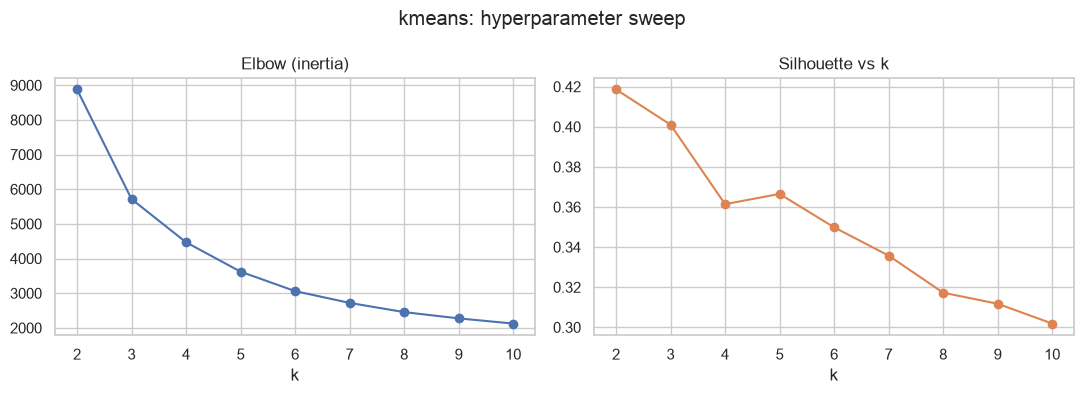

Chosen k=2 (Silhouette=0.4186)


Final metrics: {'n_clusters': 2, 'n_noise': 0, 'noise_pct': 0.0, 'largest_cluster_pct': np.float64(54.508336168764885), 'silhouette': 0.41862967470371326, 'davies_bouldin': 0.8889855828671799, 'calinski_harabasz': 5792.986253244485}
Params: {'n_clusters': 2}


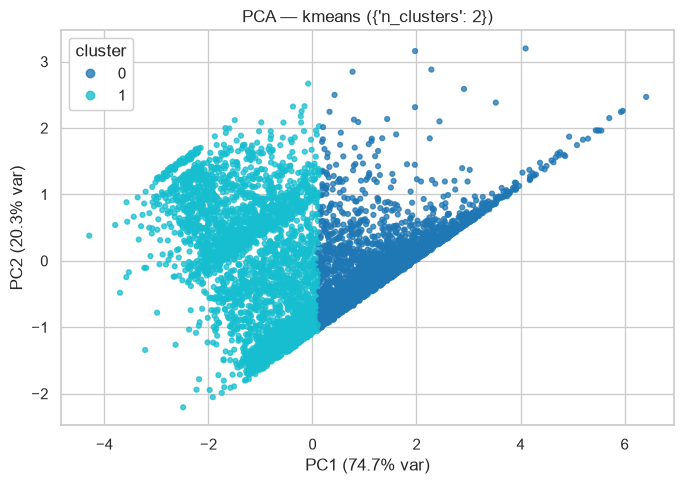

Cluster profiles (original RFM units):


,cluster,n_customers,mean_Recency,mean_Frequency,mean_Monetary,total_Monetary,pct_customers,pct_monetary
0,0,2674,62.137248,11.600598,5987.729699,1.601119e+07,45.491664,90.237288
1,1,3204,315.666667,1.856742,540.649177,1.732240e+06,54.508336,9.762712



Proper sklearn implementation: hclust → hclust


,k,inertia,n_clusters,n_noise,noise_pct,largest_cluster_pct,silhouette,davies_bouldin,calinski_harabasz
0,2,NaN,2,0,0.0,68.679823,0.399108,0.846300,5065.878657
1,3,NaN,3,0,0.0,39.622321,0.390516,0.897882,5754.578884
2,4,NaN,4,0,0.0,39.622321,0.335548,0.914784,5004.232471
3,5,NaN,5,0,0.0,39.622321,0.316921,0.934952,4701.019007
4,6,NaN,6,0,0.0,29.023477,0.303854,0.984620,4812.421559
5,7,NaN,7,0,0.0,29.023477,0.274862,1.030921,4469.068924
6,8,NaN,8,0,0.0,21.197686,0.276558,1.119493,4297.628155
7,9,NaN,9,0,0.0,21.197686,0.272939,1.078465,4140.483138
8,10,NaN,10,0,0.0,18.050357,0.233957,1.169624,3926.627379


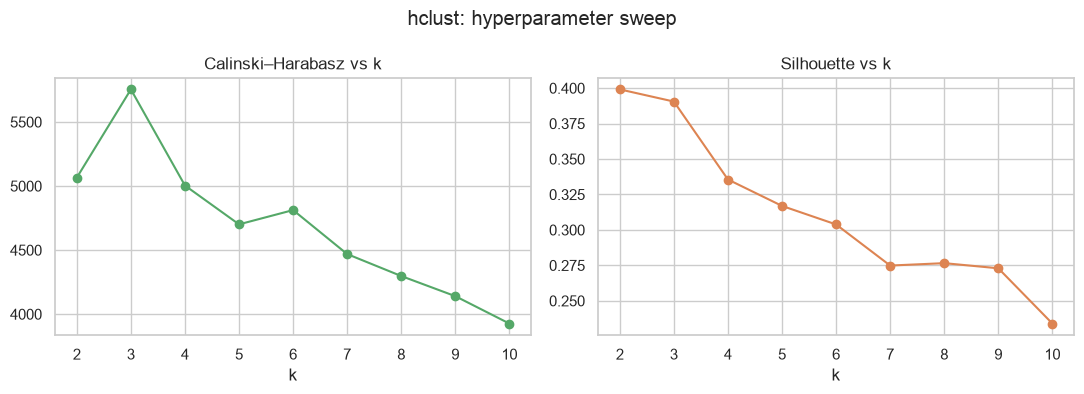

Chosen k=2 (Silhouette=0.3991)


Final metrics: {'n_clusters': 2, 'n_noise': 0, 'noise_pct': 0.0, 'largest_cluster_pct': np.float64(68.67982306907112), 'silhouette': 0.39910849834724216, 'davies_bouldin': 0.8463003357098866, 'calinski_harabasz': 5065.878657100459}
Params: {'n_clusters': 2}


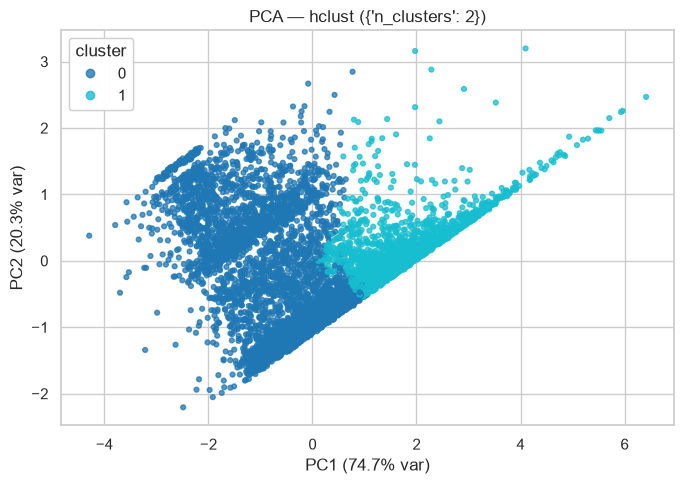

Cluster profiles (original RFM units):


,cluster,n_customers,mean_Recency,mean_Frequency,mean_Monetary,total_Monetary,pct_customers,pct_monetary
1,1,1841,57.428028,14.943509,8081.976106,1.487892e+07,31.320177,83.855933
0,0,4037,265.500619,2.342829,709.564322,2.864511e+06,68.679823,16.144067


In [10]:
ALGO_MAP = {
    "kmeans": "kmeans",
    "hclust": "hclust",
    "birch": "birch",
    "sc": "sc",
    "dbscan": "dbscan",
    "optics": "optics",
    "meanshift": "meanshift",
    "ap": "ap",
}


def fit_sklearn(algo: str, X: np.ndarray, **params):
    if algo == "kmeans":
        return KMeans(
            n_clusters=params.get("n_clusters", 4),
            random_state=SEED,
            n_init=10,
        ).fit(X)
    if algo == "hclust":
        return AgglomerativeClustering(n_clusters=params.get("n_clusters", 4)).fit(X)
    if algo == "birch":
        return Birch(n_clusters=params.get("n_clusters", 4)).fit(X)
    if algo == "sc":
        return SpectralClustering(
            n_clusters=params.get("n_clusters", 4),
            random_state=SEED,
            assign_labels="kmeans",
            affinity="nearest_neighbors",
            n_neighbors=min(15, max(2, len(X) // 50)),
        ).fit(X)
    if algo == "dbscan":
        return DBSCAN(
            eps=params.get("eps", 0.8),
            min_samples=params.get("min_samples", 10),
        ).fit(X)
    if algo == "optics":
        return OPTICS(
            min_samples=params.get("min_samples", 10),
            xi=params.get("xi", 0.05),
        ).fit(X)
    if algo == "meanshift":
        bw = params.get("bandwidth")
        if bw is None:
            bw = estimate_bandwidth(X, quantile=0.2, n_samples=min(500, len(X)), random_state=SEED)
            if not np.isfinite(bw) or bw <= 0:
                bw = 1.0
        return MeanShift(bandwidth=bw, bin_seeding=True).fit(X)
    if algo == "ap":
        return AffinityPropagation(random_state=SEED, damping=params.get("damping", 0.9)).fit(X)
    raise ValueError(algo)


def labels_from_model(model) -> np.ndarray:
    if hasattr(model, "labels_"):
        return np.asarray(model.labels_)
    raise AttributeError(type(model))


def sweep_k(algo: str, X: np.ndarray, ks=range(2, 11)):
    rows = []
    inertias = []
    for k in ks:
        model = fit_sklearn(algo, X, n_clusters=k)
        y = labels_from_model(model)
        m = internal_metrics(X, y)
        inertia = getattr(model, "inertia_", np.nan)
        inertias.append(inertia)
        rows.append({"k": k, "inertia": inertia, **m})
    return pd.DataFrame(rows)


def sweep_dbscan(X: np.ndarray):
    # k-distance heuristic for eps
    min_samples = 10
    nn = NearestNeighbors(n_neighbors=min_samples)
    nn.fit(X)
    dists, _ = nn.kneighbors(X)
    kth = np.sort(dists[:, -1])
    # candidate eps around percentiles of k-distance
    candidates = sorted(
        set(
            np.round(
                np.quantile(kth, [0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95]),
                3,
            ).tolist()
        )
    )
    rows = []
    for eps in candidates:
        for ms in [5, 10, 15]:
            model = fit_sklearn("dbscan", X, eps=eps, min_samples=ms)
            y = labels_from_model(model)
            m = internal_metrics(X, y)
            rows.append({"eps": eps, "min_samples": ms, **m})
    return pd.DataFrame(rows), kth


def profile_clusters(rfm_df: pd.DataFrame, labels: np.ndarray) -> pd.DataFrame:
    tmp = rfm_df.copy()
    tmp["cluster"] = labels
    # keep noise as -1 if present
    prof = (
        tmp.groupby("cluster")
        .agg(
            n_customers=("Customer ID", "count"),
            mean_Recency=("Recency", "mean"),
            mean_Frequency=("Frequency", "mean"),
            mean_Monetary=("Monetary", "mean"),
            total_Monetary=("Monetary", "sum"),
        )
        .reset_index()
    )
    prof["pct_customers"] = 100 * prof["n_customers"] / prof["n_customers"].sum()
    prof["pct_monetary"] = 100 * prof["total_Monetary"] / prof["total_Monetary"].sum()
    return prof.sort_values("mean_Monetary", ascending=False)


def pca_scatter(X: np.ndarray, labels: np.ndarray, title: str):
    pca = PCA(n_components=2, random_state=SEED)
    Z = pca.fit_transform(X)
    fig, ax = plt.subplots(figsize=(7, 5))
    scatter = ax.scatter(Z[:, 0], Z[:, 1], c=labels, cmap="tab10", s=12, alpha=0.75)
    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% var)")
    ax.set_ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% var)")
    legend = ax.legend(*scatter.legend_elements(), title="cluster", loc="best")
    ax.add_artist(legend)
    plt.tight_layout()
    plt.show()
    return pca


proper_results = {}

for mid in best_two:
    algo = ALGO_MAP[mid]
    print("\n" + "=" * 70)
    print(f"Proper sklearn implementation: {mid} → {algo}")
    print("=" * 70)

    if algo in {"kmeans", "hclust", "birch", "sc"}:
        sweep = sweep_k(algo, X_scaled, ks=range(2, 11))
        display(sweep)

        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        if sweep["inertia"].notna().any() and algo == "kmeans":
            axes[0].plot(sweep["k"], sweep["inertia"], marker="o")
            axes[0].set_title("Elbow (inertia)")
        else:
            axes[0].plot(sweep["k"], sweep["calinski_harabasz"], marker="o", color="C2")
            axes[0].set_title("Calinski–Harabasz vs k")
        axes[0].set_xlabel("k")
        axes[1].plot(sweep["k"], sweep["silhouette"], marker="o", color="C1")
        axes[1].set_title("Silhouette vs k")
        axes[1].set_xlabel("k")
        plt.suptitle(f"{algo}: hyperparameter sweep")
        plt.tight_layout()
        plt.show()

        # Choose k: max silhouette among k with largest_cluster_pct < 92
        viable = sweep.loc[sweep["largest_cluster_pct"] < 92].copy()
        if viable.empty:
            viable = sweep.copy()
        best_row = viable.sort_values(
            ["silhouette", "calinski_harabasz"], ascending=[False, False]
        ).iloc[0]
        best_k = int(best_row["k"])
        print(f"Chosen k={best_k} (Silhouette={best_row['silhouette']:.4f})")
        model = fit_sklearn(algo, X_scaled, n_clusters=best_k)
        y = labels_from_model(model)
        params_used = {"n_clusters": best_k}
        sweep_table = sweep

    elif algo == "dbscan":
        sweep, kth = sweep_dbscan(X_scaled)
        display(sweep.sort_values("silhouette", ascending=False).head(15))
        fig, ax = plt.subplots(figsize=(8, 3.5))
        ax.plot(kth)
        ax.set_title("k-distance plot (sorted distance to min_samples-th neighbor)")
        ax.set_xlabel("points sorted by k-distance")
        ax.set_ylabel("distance")
        plt.tight_layout()
        plt.show()

        viable = sweep.loc[
            (sweep["n_clusters"] >= 2)
            & (sweep["noise_pct"] <= 40)
            & (sweep["largest_cluster_pct"] < 92)
        ].copy()
        if viable.empty:
            viable = sweep.loc[sweep["n_clusters"] >= 2].copy()
        best_row = viable.sort_values("silhouette", ascending=False).iloc[0]
        params_used = {
            "eps": float(best_row["eps"]),
            "min_samples": int(best_row["min_samples"]),
        }
        print("Chosen DBSCAN params:", params_used)
        model = fit_sklearn("dbscan", X_scaled, **params_used)
        y = labels_from_model(model)
        sweep_table = sweep

    elif algo == "optics":
        rows = []
        for ms in [5, 10, 15, 20]:
            for xi in [0.03, 0.05, 0.1]:
                model = fit_sklearn("optics", X_scaled, min_samples=ms, xi=xi)
                y_try = labels_from_model(model)
                m = internal_metrics(X_scaled, y_try)
                rows.append({"min_samples": ms, "xi": xi, **m})
        sweep = pd.DataFrame(rows)
        display(sweep.sort_values("silhouette", ascending=False).head(15))
        viable = sweep.loc[
            (sweep["n_clusters"] >= 2) & (sweep["noise_pct"] <= 40)
        ].copy()
        if viable.empty:
            viable = sweep.loc[sweep["n_clusters"] >= 2].copy()
        best_row = viable.sort_values("silhouette", ascending=False).iloc[0]
        params_used = {
            "min_samples": int(best_row["min_samples"]),
            "xi": float(best_row["xi"]),
        }
        print("Chosen OPTICS params:", params_used)
        model = fit_sklearn("optics", X_scaled, **params_used)
        y = labels_from_model(model)
        sweep_table = sweep

    elif algo == "meanshift":
        rows = []
        for q in [0.1, 0.15, 0.2, 0.25, 0.3]:
            bw = estimate_bandwidth(
                X_scaled, quantile=q, n_samples=min(500, len(X_scaled)), random_state=SEED
            )
            if not np.isfinite(bw) or bw <= 0:
                continue
            model = fit_sklearn("meanshift", X_scaled, bandwidth=bw)
            y_try = labels_from_model(model)
            m = internal_metrics(X_scaled, y_try)
            rows.append({"quantile": q, "bandwidth": bw, **m})
        sweep = pd.DataFrame(rows)
        display(sweep)
        viable = sweep.loc[sweep["n_clusters"] >= 2].copy()
        best_row = viable.sort_values("silhouette", ascending=False).iloc[0]
        params_used = {"bandwidth": float(best_row["bandwidth"]), "quantile": float(best_row["quantile"])}
        print("Chosen MeanShift params:", params_used)
        model = fit_sklearn("meanshift", X_scaled, bandwidth=params_used["bandwidth"])
        y = labels_from_model(model)
        sweep_table = sweep

    elif algo == "ap":
        rows = []
        for damp in [0.5, 0.7, 0.9]:
            model = fit_sklearn("ap", X_scaled, damping=damp)
            y_try = labels_from_model(model)
            m = internal_metrics(X_scaled, y_try)
            rows.append({"damping": damp, **m})
        sweep = pd.DataFrame(rows)
        display(sweep)
        best_row = sweep.sort_values("silhouette", ascending=False).iloc[0]
        params_used = {"damping": float(best_row["damping"])}
        print("Chosen AffinityPropagation params:", params_used)
        model = fit_sklearn("ap", X_scaled, **params_used)
        y = labels_from_model(model)
        sweep_table = sweep
    else:
        raise ValueError(algo)

    metrics = internal_metrics(X_scaled, y)
    print("Final metrics:", metrics)
    print("Params:", params_used)
    pca_scatter(X_scaled, y, f"PCA — {algo} ({params_used})")
    prof = profile_clusters(rfm, y)
    print("Cluster profiles (original RFM units):")
    display(prof)

    proper_results[mid] = {
        "algo": algo,
        "params": params_used,
        "labels": y,
        "metrics": metrics,
        "profile": prof,
        "sweep": sweep_table,
    }

## 7. Side-by-side comparison of the two properly implemented models

Higher Silhouette is not always the business winner. A technically better score with
a 90/10 split that marketing cannot act on is a real judgment call — we surface it.

In [11]:
cmp_rows = []
for mid, res in proper_results.items():
    m = res["metrics"]
    cmp_rows.append(
        {
            "model": mid,
            "algo": res["algo"],
            "params": res["params"],
            "n_clusters": m["n_clusters"],
            "noise_pct": m["noise_pct"],
            "largest_cluster_pct": m["largest_cluster_pct"],
            "silhouette": m["silhouette"],
            "davies_bouldin": m["davies_bouldin"],
            "calinski_harabasz": m["calinski_harabasz"],
        }
    )
comparison = pd.DataFrame(cmp_rows)
display(comparison)

# Interpretability judgment from profiles
for mid, res in proper_results.items():
    prof = res["profile"]
    usable = prof.loc[prof["cluster"] >= 0]
    print(f"\n{mid} interpretability notes:")
    print(
        f"  clusters={res['metrics']['n_clusters']}, "
        f"largest={res['metrics']['largest_cluster_pct']:.1f}%, "
        f"noise={res['metrics']['noise_pct']:.1f}%"
    )
    if len(usable):
        spread_m = usable["mean_Monetary"].max() / max(usable["mean_Monetary"].min(), 1e-9)
        spread_f = usable["mean_Frequency"].max() / max(usable["mean_Frequency"].min(), 1e-9)
        print(f"  monetary mean ratio (max/min)={spread_m:.2f}")
        print(f"  frequency mean ratio (max/min)={spread_f:.2f}")
        display(usable)

# Prefer model with good silhouette AND separable monetary profiles
def business_score(row) -> float:
    s = 0.0 if pd.isna(row["silhouette"]) else float(row["silhouette"])
    if row["noise_pct"] > 30:
        s -= 0.3
    if row["largest_cluster_pct"] > 85:
        s -= 0.2
    return s


comparison["business_score"] = comparison.apply(business_score, axis=1)
preferred = comparison.sort_values("business_score", ascending=False).iloc[0]
print(
    "\nPreferred for business use (metric + balance):",
    preferred["model"],
    "params=",
    preferred["params"],
    f"Silhouette={preferred['silhouette']:.4f}",
)

,model,algo,params,n_clusters,noise_pct,largest_cluster_pct,silhouette,davies_bouldin,calinski_harabasz
0,kmeans,kmeans,{'n_clusters': 2},2,0.0,54.508336,0.418630,0.888986,5792.986253
1,hclust,hclust,{'n_clusters': 2},2,0.0,68.679823,0.399108,0.846300,5065.878657



kmeans interpretability notes:
  clusters=2, largest=54.5%, noise=0.0%
  monetary mean ratio (max/min)=11.08
  frequency mean ratio (max/min)=6.25


,cluster,n_customers,mean_Recency,mean_Frequency,mean_Monetary,total_Monetary,pct_customers,pct_monetary
0,0,2674,62.137248,11.600598,5987.729699,1.601119e+07,45.491664,90.237288
1,1,3204,315.666667,1.856742,540.649177,1.732240e+06,54.508336,9.762712



hclust interpretability notes:
  clusters=2, largest=68.7%, noise=0.0%
  monetary mean ratio (max/min)=11.39
  frequency mean ratio (max/min)=6.38


,cluster,n_customers,mean_Recency,mean_Frequency,mean_Monetary,total_Monetary,pct_customers,pct_monetary
1,1,1841,57.428028,14.943509,8081.976106,1.487892e+07,31.320177,83.855933
0,0,4037,265.500619,2.342829,709.564322,2.864511e+06,68.679823,16.144067



Preferred for business use (metric + balance): kmeans params= {'n_clusters': 2} Silhouette=0.4186


## 8. Explaining this to your manager

Below is a plain-language wrap-up generated from **this run’s** preferred model
and its cluster profiles — not a canned tutorial story.

In [12]:
pref_mid = preferred["model"]
pref = proper_results[pref_mid]
prof = pref["profile"].loc[pref["profile"]["cluster"] >= 0].copy()
prof = prof.sort_values("mean_Monetary", ascending=False).reset_index(drop=True)

print("MANAGER BRIEF — Online Retail II RFM segments")
print("=" * 60)
print(
    f"We grouped {len(rfm):,} customers into {pref['metrics']['n_clusters']} segments "
    f"using {pref['algo']} {pref['params']} (unsupervised; no ground-truth labels)."
)
print(
    f"Internal fit: Silhouette={pref['metrics']['silhouette']:.3f}, "
    f"Davies–Bouldin={pref['metrics']['davies_bouldin']:.3f}, "
    f"Calinski–Harabasz={pref['metrics']['calinski_harabasz']:.1f}."
)
print()

actions = [
    "VIP treatment: dedicated account touches, early access, high-touch retention.",
    "Growth nurture: cross-sell bundles and loyalty incentives to raise frequency.",
    "Reactivation: win-back email/SMS timed to recency decay with a modest incentive.",
    "Efficient automation: low-cost lifecycle messaging; avoid heavy discounts.",
    "Watchlist: investigate if high recency + low monetary indicates friction.",
]

for i, row in prof.iterrows():
    action = actions[min(i, len(actions) - 1)]
    print(
        f"Segment {int(row['cluster'])}: n={int(row['n_customers'])} "
        f"({row['pct_customers']:.1f}% of customers, {row['pct_monetary']:.1f}% of revenue). "
        f"Avg Recency={row['mean_Recency']:.0f}d, Frequency={row['mean_Frequency']:.1f}, "
        f"Monetary=£{row['mean_Monetary']:.0f}."
    )
    print(f"  → Action: {action}")
print()
print(
    "Bottom line: concentrate retention budget on high-monetary, lower-recency-days "
    "segments; use cheaper automation on low-value infrequent buyers; treat mid-tier "
    "as growth opportunities rather than discounting them into unprofitability."
)

MANAGER BRIEF — Online Retail II RFM segments
We grouped 5,878 customers into 2 segments using kmeans {'n_clusters': 2} (unsupervised; no ground-truth labels).
Internal fit: Silhouette=0.419, Davies–Bouldin=0.889, Calinski–Harabasz=5793.0.

Segment 0: n=2674 (45.5% of customers, 90.2% of revenue). Avg Recency=62d, Frequency=11.6, Monetary=£5988.
  → Action: VIP treatment: dedicated account touches, early access, high-touch retention.
Segment 1: n=3204 (54.5% of customers, 9.8% of revenue). Avg Recency=316d, Frequency=1.9, Monetary=£541.
  → Action: Growth nurture: cross-sell bundles and loyalty incentives to raise frequency.

Bottom line: concentrate retention budget on high-monetary, lower-recency-days segments; use cheaper automation on low-value infrequent buyers; treat mid-tier as growth opportunities rather than discounting them into unprofitability.


## 9. What we did **not** claim

- We did **not** report classification accuracy — there is no true segment label.
- PyCaret’s survey narrowed the field; **scikit-learn** re-fits with real
  hyperparameter sweeps are the deliverable models.
- Internal metrics judge cluster geometry, not campaign lift. Online A/B tests
  would be the next step before spending marketing budget at scale.